In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, classification_report, PrecisionRecallDisplay, precision_recall_curve
from sklearn.model_selection import train_test_split
import warnings

Partition Data

In [ ]:
SEED = 42

scaler = StandardScaler()
raw_df = pd.read_csv("/content/sample_data/creditcard.csv")

#learned pop from Gemini
#returns colum and removes it from dataset
raw_y = raw_df.pop("Class")
raw_X = raw_df

#60/20/20 split recommended - Gemini

#split into development and test sets
dev_X, test_X, dev_y, test_y = train_test_split(
    raw_X,
    raw_y,
    test_size = 0.2,
    random_state = SEED,
    stratify = raw_y
)

#split into train and validation sets
train_X, val_X, train_y, val_y = train_test_split(
    dev_X,
    dev_y,
    test_size = 0.25, #25% of 80 is 20
    random_state = SEED,
    stratify = dev_y
)

#scale data
train_X_scaled = scaler.fit_transform(train_X)
val_X_scaled = scaler.transform(val_X)
test_X_scaled = scaler.transform(test_X)

Model and Metrics

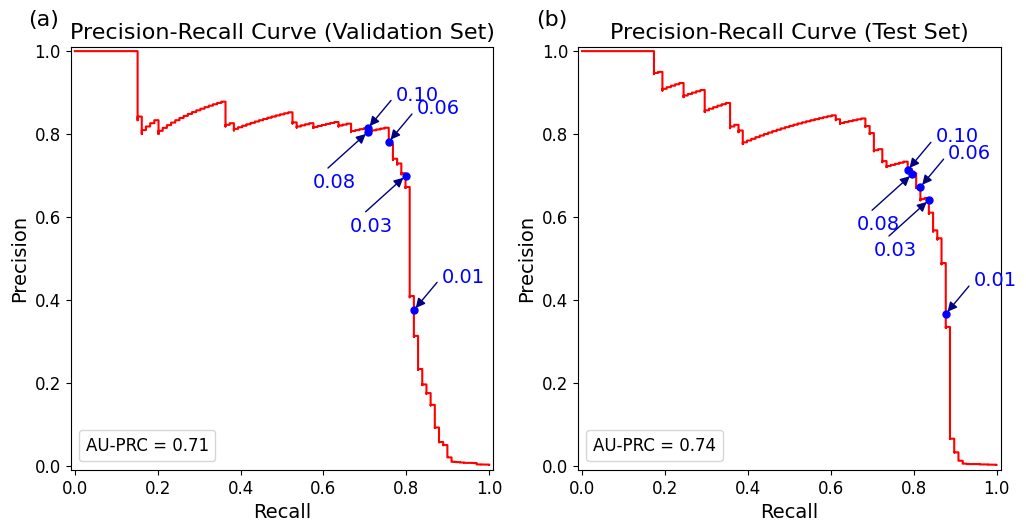

In [ ]:
EPOCHS = 1000
OFFSET = np.array([20, 20])

#model
model = LogisticRegression(max_iter=EPOCHS, random_state=SEED)
model.fit(train_X_scaled, train_y)

#PRC curve with thresholds, some code adapted from Gemini
spec_thresholds = np.linspace(.01, .1, 5) #thresholds to examine

#creates graph
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

#font size code by Gemini
plt.rcParams.update({
    'font.size': 14,          # General font size
    'axes.titlesize': 16,     # Plot titles (e.g., "Precision-Recall Curve...")
    'axes.labelsize': 14,     # X and Y axis labels ("Recall", "Precision")
    'xtick.labelsize': 12,    # Numbers on the X-axis (0.0, 0.2, etc.)
    'ytick.labelsize': 12,    # Numbers on the Y-axis
    'legend.fontsize': 12     # Text inside the legend
})

def plotGraph(ax, setName, letter, X, y):
  y_probs = model.predict_proba(X)[:, 1] #all rows, second column (probability of positive)
  precision, recall, thresholds = precision_recall_curve(y, y_probs) #all possible thresholds w/ precision and recall

  #plots graph
  display = PrecisionRecallDisplay.from_estimator(model, X, y, ax=ax, color="red")
  ax.set_title(f"Precision-Recall Curve ({setName} Set)")
  ax.set_xlabel("Recall")
  ax.set_ylabel("Precision")

  #Legend and letter label code by Gemini
  display.line_.set_label(f"AU-PRC = {display.average_precision:.2f}")
  ax.legend(loc="lower left", handlelength=0, handletextpad=0)
  ax.text(-.1, 1.05, "(" + letter + ")", transform=ax.transAxes, fontsize=16)

  #plots thresholds
  for j, t in enumerate(spec_thresholds):
    index = np.argmin(np.abs(thresholds - t)) #closest threshold to t

    rec = recall[index]
    prec = precision[index]

    #dot
    ax.plot(rec, prec, marker='o', color="blue", markersize=5)

    #label
    ax.annotate(
        f"{t:.2f}",
        (rec, prec),
        xytext=OFFSET * (-2 if j % 2 == 1 else 1),
        color="blue",
        textcoords="offset points",
        arrowprops=dict(
            arrowstyle="-|>",
            color="navy",
            relpos=(0,.5)
          )
      )

plotGraph(ax[0], "Validation", "a", val_X_scaled, val_y)
plotGraph(ax[1], "Test", "b", test_X_scaled, test_y)

plt.show()


Recall is more important than precision as a false negative is more costly. Choosing a threshold of 0.03

In [ ]:
THRESHOLD = .03

test_probs = model.predict_proba(test_X_scaled)[:, 1]
test_preds = (test_probs > THRESHOLD).astype(int)

recall = recall_score(test_y, test_preds)
precision = precision_score(test_y, test_preds)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Recall: {recall:.3f}")
print(f"Precision: {precision:.3f}")
print(f"F1 Score: {f1_score:.3f}")

Recall: 0.837
Precision: 0.631
F1 Score: 0.719
